# Project 3: Developer Burnout Data Analysis

The main goal of this project is to analyze developer burnout by examining how various work-related and lifestyle factors influence burnout levels. Using data analysis techniques in Python, the project explores patterns within the data to better understand the relationship between factors such as stress, working hours, sleep, and productivity, and how they contribute to burnout among developers.

For the Project ill be using the following libraries:
Pandas,Matplotlib.pyplot,seaborn.
I also got my Dataset from Kaggel.

**Data Cleaning:**

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
bu=pd.read_csv("developer_burnout_dataset_7000.csv")

Dataframe Explantion:
The dataset contains information about 7,000 developers and includes columns related to their personal characteristics, work habits, lifestyle, and productivity.


Columns Explanation:
age: Age of the developer (years)
experience_years: Total years of programming experience
daily_work_hours: Average number of working hours per day
sleep_hours: Average sleep duration per day (hours)
caffeine_intake: Number of caffeinated drinks consumed per day
bugs_per_day: Average number of bugs produced per day
commits_per_day: Number of code commits per day
meetings_per_day: Number of meetings attended daily
screen_time: Total screen exposure time per day (hours)
exercise_hours: Daily time spent on physical exercise (hours)
stress_level: Calculated stress score (0–100)
burnout_level: Target variable indicating burnout status (Low / Medium / High)

In [3]:
bu.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [4]:
bu.tail()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium
6999,25.0,2.0,4.35,4.83,1.0,16.0,23.0,4.0,8.52,1.98,39.18,Medium


In [5]:
bu.info() #we can see the all the columns except "burnout_level" are float, they are suitable for calculations

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   str    
dtypes: float64(11), str(1)
memory usage: 656.4 KB


In [6]:
bu.age.min() #we can see the minimum age in our data is 20

np.float64(20.0)

In [7]:
bu.age.max() #we can see the maximum age in our data is 44

np.float64(44.0)

In [8]:
bu.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


In [9]:
#we are checking the statistics on developers between the ages of 20 - 44

In [10]:
len(bu) 

7000

In [11]:
bu.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [12]:
#The dataset contains 7000 rows, with 140 missing values in each column.

In [13]:
bu = bu[bu["burnout_level"].notna()] 
#dropping all the values that are null in this column because this is the column ill be using for measuring burnout level
# so filling it would result in wrong data 

In [14]:
med_age = bu["age"].median()
med_experiance = bu["experience_years"].median()
med_daily_hours = bu["daily_work_hours"].median()
med_sleep_hours = bu["sleep_hours"].median()
med_caffeine_intake = bu["caffeine_intake"].median()
med_bugs = bu["bugs_per_day"].median()
med_commits = bu["commits_per_day"].median()
med_meetings = bu["meetings_per_day"].median()
med_screen_time = bu["screen_time"].median()
med_excercise_hours = bu["exercise_hours"].median()
med_stress_level = bu["stress_level"].median()
bu["age"] = bu["age"].fillna(med_age)
bu["experience_years"] = bu["experience_years"].fillna(med_experiance)
bu["daily_work_hours"] = bu["daily_work_hours"].fillna(med_daily_hours)
bu["sleep_hours"] = bu["sleep_hours"].fillna(med_sleep_hours)
bu["caffeine_intake"] = bu["caffeine_intake"].fillna(med_caffeine_intake)
bu["bugs_per_day"] = bu["bugs_per_day"].fillna(med_bugs)
bu["commits_per_day"] = bu["commits_per_day"].fillna(med_commits)
bu["meetings_per_day"] = bu["meetings_per_day"].fillna(med_meetings)
bu["screen_time"] = bu["screen_time"].fillna(med_screen_time)
bu["exercise_hours"] = bu["exercise_hours"].fillna(med_excercise_hours)
bu["stress_level"] = bu["stress_level"].fillna(med_stress_level)

In [15]:
#filling the nulls in those columns with the median to perserve the values of the other columns and the dataset size

In [16]:
bu.isnull().sum()#no nulls now 

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64

In [17]:
bu.duplicated().sum() # check for duplicate rows was performed, and no duplicates were found in the dataset

np.int64(0)

In [18]:
bu.burnout_level.unique() # checked that the column burnout_level has 3 valid and realistic values for for analysis 

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [19]:
bu.describe()#checking the data statistics after removing the nulls

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129592,9.587172,8.988819,6.484554,3.555539,9.457580,14.417347,4.557289,11.964254,1.007048,53.613703
std,7.148293,5.699360,2.838615,1.429694,2.261252,5.696747,8.585820,2.830655,3.061446,0.571074,23.242928
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.580000,5.250000,2.000000,5.000000,7.000000,2.000000,9.510000,0.520000,36.887500
50%,32.000000,10.000000,8.980000,6.460000,4.000000,9.000000,14.000000,5.000000,12.010000,1.020000,53.745000
75%,38.000000,15.000000,11.362500,7.710000,6.000000,14.000000,22.000000,7.000000,14.360000,1.490000,70.452500
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


In [20]:
bu["stress_level"].describe() #checking the statistics for the stress_level column to make sure all the values are in range 0-100

count    6860.000000
mean       53.613703
std        23.242928
min         0.000000
25%        36.887500
50%        53.745000
75%        70.452500
max       100.000000
Name: stress_level, dtype: float64

In [21]:
# examined for inconsistent data like unreasonable min,max,mean and after examining the data, all values seem normal 
#for the context of the analysis

In [22]:
bu["stress_level"] = bu["stress_level"] /10

In [23]:
#The stress level variable was converted from a 0–100 scale to a 0–10 scale for better interpretability

In [24]:
bu["stress_level"].describe()

count    6860.000000
mean        5.361370
std         2.324293
min         0.000000
25%         3.688750
50%         5.374500
75%         7.045250
max        10.000000
Name: stress_level, dtype: float64

In [25]:
bu["employee_id"] = range(1, len(bu) + 1) #creating an index column for each employee

In [26]:
bu["work_intensity"] = bu["daily_work_hours"] * bu["stress_level"] #creating a column to calculate work intensity
# by multiplying the  work hours by the intensity of them

In [27]:
bu["lifestyle_score"] = bu["sleep_hours"] + bu["exercise_hours"] #creating a column to caculate the lifestyle quality of employees
# by summing the two lifestyle indicators we have for the employee

In [28]:
bu["productivity_load"] = bu["commits_per_day"] + bu["bugs_per_day"] + bu["meetings_per_day"]
#creating a column to sum all types of workloads for the employee into one measure

In [29]:
high_burnout = bu[bu["burnout_level"] == 'High'] #all the data where the burnout_level is high

In [30]:
high_burnout.sort_values(by="stress_level", ascending=False).head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,employee_id,work_intensity,lifestyle_score,productivity_load
6212,24.0,16.0,11.97,6.45,4.0,14.0,0.0,7.0,13.31,0.74,10.0,High,6081,119.7,7.19,21.0
2790,36.0,0.0,7.33,5.36,3.0,19.0,3.0,9.0,9.14,0.96,10.0,High,2730,73.3,6.32,31.0
4559,41.0,3.0,13.18,4.92,7.0,9.0,0.0,5.0,14.29,1.23,10.0,High,4465,131.8,6.15,14.0
913,34.0,18.0,10.66,5.24,6.0,18.0,21.0,9.0,13.28,0.89,10.0,High,898,106.6,6.13,48.0
4566,41.0,1.0,12.80,5.34,6.0,19.0,4.0,5.0,15.65,1.69,10.0,High,4471,128.0,7.03,28.0


In [31]:
high_stress = bu[bu["stress_level"] > 7]#all the data where the stress_level is highe then 7 

In [32]:
high_stress.sort_values(by="stress_level", ascending=False).head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,employee_id,work_intensity,lifestyle_score,productivity_load
1410,33.0,0.0,13.36,6.01,2.0,16.0,2.0,6.0,17.36,0.24,10.0,High,1386,133.6,6.25,24.0
6483,39.0,10.0,13.82,4.74,6.0,17.0,8.0,9.0,17.00,0.99,10.0,High,6348,138.2,5.73,34.0
540,30.0,13.0,13.84,4.31,6.0,9.0,23.0,6.0,16.25,1.26,10.0,High,530,138.4,5.57,38.0
1768,32.0,16.0,12.86,7.06,5.0,16.0,11.0,5.0,12.01,0.03,10.0,High,1737,128.6,7.09,32.0
6562,44.0,8.0,10.21,5.34,3.0,16.0,3.0,9.0,14.22,0.25,10.0,High,6427,102.1,5.59,28.0


In [33]:
len(high_stress)

1758

In [34]:
len(high_burnout)

1782

In [35]:
stress_burnout_correlation=pd.merge(high_burnout,high_stress,on="employee_id")

In [36]:
len(stress_burnout_correlation)

1758

In [37]:
#after performing a merge on high_stress and high_burnout, we got 1758 results, which is the same count as the result of high_stress
# We can infer from it that all the employees who experience high stress also experience high burnout
# In the high_burnout variable, we have 1782 results. We can infer that other factors cause high burnout

In [38]:
low_lifestyle_score = bu[bu["lifestyle_score"] <6]

In [39]:
low_lifestyle_score.sort_values(by="lifestyle_score",ascending=False).head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,employee_id,work_intensity,lifestyle_score,productivity_load
898,29.0,6.0,12.70,5.78,7.0,15.0,16.0,0.0,15.21,0.21,8.862,High,883,112.5474,5.99,31.0
259,27.0,4.0,7.38,4.15,3.0,18.0,20.0,9.0,10.02,1.84,9.520,High,256,70.2576,5.99,47.0
5359,43.0,13.0,10.11,5.53,0.0,15.0,1.0,3.0,13.03,0.46,6.150,Medium,5245,62.1765,5.99,19.0
593,39.0,11.0,4.50,4.79,1.0,16.0,1.0,9.0,6.69,1.20,6.480,Medium,583,29.1600,5.99,26.0
1691,42.0,18.0,11.80,5.38,4.0,9.0,26.0,6.0,16.08,0.61,8.227,High,1660,97.0786,5.99,41.0


In [40]:
len(low_lifestyle_score)

1349

In [41]:
lifestyle_burnout_correlation=pd.merge(high_burnout,low_lifestyle_score, on="employee_id")

In [42]:
len(lifestyle_burnout_correlation)

512

In [43]:
# after performing a merge on high_stress and low_lifestyle_score we got 512 results,
# This means 512 employees experience burnout and have a low lifestyle score
# The count of low_lifestyle_score is 1349 results, we can infer that not all employees who have a low lifestyle score experience burnout

In [44]:
bu.sort_values(by="work_intensity", ascending=False).head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,employee_id,work_intensity,lifestyle_score,productivity_load
661,36.0,4.0,14.00,5.29,2.0,19.0,9.0,5.0,15.28,0.43,10.0,High,651,140.0,5.72,33.0
323,40.0,17.0,13.99,5.39,4.0,15.0,6.0,3.0,15.86,0.86,10.0,High,320,139.9,6.25,24.0
456,36.0,8.0,13.97,4.75,7.0,11.0,4.0,5.0,16.58,1.26,10.0,High,448,139.7,6.01,20.0
581,42.0,1.0,13.92,4.62,7.0,9.0,9.0,9.0,18.16,1.43,10.0,High,571,139.2,6.05,27.0
413,35.0,11.0,13.92,4.24,3.0,11.0,22.0,5.0,16.46,1.20,10.0,High,406,139.2,5.44,38.0


In [45]:
bu.sort_values(by="lifestyle_score", ascending=False).head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,employee_id,work_intensity,lifestyle_score,productivity_load
734,27.0,19.0,9.23,8.98,5.0,9.0,19.0,3.0,11.94,1.99,1.895,Low,724,17.49085,10.97,31.0
4258,31.0,5.0,11.57,8.99,5.0,19.0,21.0,7.0,13.38,1.95,7.096,High,4170,82.10072,10.94,47.0
5399,25.0,7.0,9.58,8.97,7.0,0.0,20.0,2.0,13.49,1.95,1.609,Low,5283,15.41422,10.92,22.0
6479,34.0,0.0,12.53,9.00,6.0,6.0,29.0,0.0,17.23,1.89,4.455,Medium,6344,55.82115,10.89,35.0
1906,43.0,14.0,6.63,8.93,3.0,14.0,24.0,7.0,8.37,1.94,4.442,Medium,1869,29.45046,10.87,45.0


In [46]:
bu.groupby("burnout_level").mean()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,employee_id,work_intensity,lifestyle_score,productivity_load
burnout_level,,,,,,,,,,,,,,,
High,32.278339,9.450617,11.124837,6.093131,4.115600,13.168350,14.363075,5.732323,14.076930,0.926184,8.274639,3411.450617,92.638209,7.019315,33.263749
Low,32.044570,9.745763,6.741513,6.972128,2.965474,5.812932,14.670433,3.166353,9.750847,1.084488,2.276814,3425.686755,15.850848,8.056616,23.649718
Medium,32.092396,9.584505,8.923848,6.461831,3.538881,9.226112,14.329412,4.592253,11.895722,1.012999,5.281672,3442.440746,47.908809,7.474829,28.147776


In [47]:
#The analysis shows that higher burnout levels are strongly associated with longer working hours, increased screen time, and a higher 
#number of meetings and bugs per day. 
#Additionally, developers with higher burnout tend to sleep fewer hours, indicating a potential impact on well-being. 
#In contrast, age and experience do not show significant differences across burnout levels, suggesting that burnout is more 
#influenced by work conditions than by demographic factors.

In [48]:
bu.groupby("burnout_level")["work_intensity"].mean() #seeing here that the higher the work intensity the higher the burnout level

burnout_level
High      92.638209
Low       15.850848
Medium    47.908809
Name: work_intensity, dtype: float64

In [49]:
bu.groupby("burnout_level")["lifestyle_score"].mean() #seeing here that those who have lower lifestyle score wxperience higher burnout

burnout_level
High      7.019315
Low       8.056616
Medium    7.474829
Name: lifestyle_score, dtype: float64

In [50]:
bu.groupby("burnout_level")["productivity_load"].mean()#seeing here that the more workload you have the more burntout you are

burnout_level
High      33.263749
Low       23.649718
Medium    28.147776
Name: productivity_load, dtype: float64

In [51]:
bu.groupby("burnout_level")[["productivity_load","lifestyle_score","work_intensity"]].mean()

,productivity_load,lifestyle_score,work_intensity
burnout_level,,,
High,33.263749,7.019315,92.638209
Low,23.649718,8.056616,15.850848
Medium,28.147776,7.474829,47.908809


In [52]:
#we can see here that burnout is effected and is affecting different parameters in an employees work and personal life

In [53]:
bu.burnout_level.value_counts().to_frame() #the number of values in each burnout level category

,count
burnout_level,
Medium,3485
High,1782
Low,1593


In [54]:
burnout_destribution = bu.burnout_level.value_counts().sort_values(ascending=False)

In [55]:
burnout_destribution

burnout_level
Medium    3485
High      1782
Low       1593
Name: count, dtype: int64

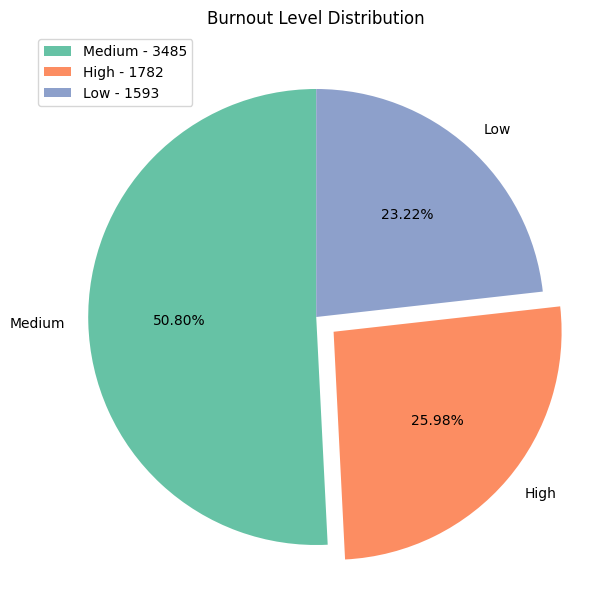

In [56]:
legend_vals = []
for label, value in burnout_destribution.items():
    legend_vals.append(f"{label} - {value}")
plt.figure(figsize=(10,6))
plt.pie(burnout_destribution,explode=(0,0.1,0),autopct="%1.2f%%",startangle=90,labels=burnout_destribution.index,colors = ['#66c2a5', '#fc8d62', '#8da0cb'])
plt.legend(legend_vals,loc="upper left")
plt.tight_layout()
plt.title("Burnout Level Distribution")
plt.show()

In this part of the project, a pie chart was created to visualize the distribution of burnout levels. First, a list of legend labels was built by iterating over the burnout distribution data and combining each category with its corresponding count. Then, a figure was initialized to control the size of the plot. The pie chart was generated using plt.pie(), where the data was displayed as percentages, and one slice was slightly separated to highlight it. Finally, a custom legend was added using the wedge objects and the prepared labels, and the chart was given a descriptive title.

The pie chart shows the distribution of developers across different burnout levels. The majority of developers fall into the medium burnout category, which accounts for the largest portion of the chart. A smaller proportion of developers experience high burnout, while the lowest percentage is observed in the low burnout category. This indicates that burnout is common among developers, with many experiencing at least a moderate level.

In [57]:
bu

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,employee_id,work_intensity,lifestyle_score,productivity_load
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,5.596,Medium,1,57.80668,4.59,16.0
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,8.222,High,2,70.87364,6.31,31.0
2,34.0,13.0,8.98,4.03,5.0,2.0,18.0,9.0,11.18,1.54,6.177,Medium,3,55.46946,5.57,29.0
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,5.498,Medium,4,37.66130,7.43,42.0
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,2.790,Low,5,11.82960,6.16,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,2.010,Low,6856,13.12530,9.10,13.0
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,4.171,Medium,6857,42.33565,6.56,13.0
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,8.015,High,6858,68.60840,7.84,25.0
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,4.144,Medium,6859,18.19216,6.22,15.0


In [58]:
bu= bu.rename(columns={"burnout_level":"Burnout Level",
                       "work_intensity":"Work Intensity",
                       "lifestyle_score":"Lifestyle Score",
                       "productivity_load":"Productivity Load",
                      "stress_level":"Stress Level",
                      "sleep_hours":"Sleep Hours",
                      "exercise_hours":"Exercise Hours",
                      "screen_time":"Screen Time",
                      "meetings_per_day":"Meetings Per Day",
                      "bugs_per_day":"Bugs Per Day",
                      "commits_per_day":"Commits Per Day"})

In [59]:
bu

,age,experience_years,daily_work_hours,Sleep Hours,caffeine_intake,Bugs Per Day,Commits Per Day,Meetings Per Day,Screen Time,Exercise Hours,Stress Level,Burnout Level,employee_id,Work Intensity,Lifestyle Score,Productivity Load
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,5.596,Medium,1,57.80668,4.59,16.0
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,8.222,High,2,70.87364,6.31,31.0
2,34.0,13.0,8.98,4.03,5.0,2.0,18.0,9.0,11.18,1.54,6.177,Medium,3,55.46946,5.57,29.0
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,5.498,Medium,4,37.66130,7.43,42.0
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,2.790,Low,5,11.82960,6.16,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,2.010,Low,6856,13.12530,9.10,13.0
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,4.171,Medium,6857,42.33565,6.56,13.0
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,8.015,High,6858,68.60840,7.84,25.0
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,4.144,Medium,6859,18.19216,6.22,15.0


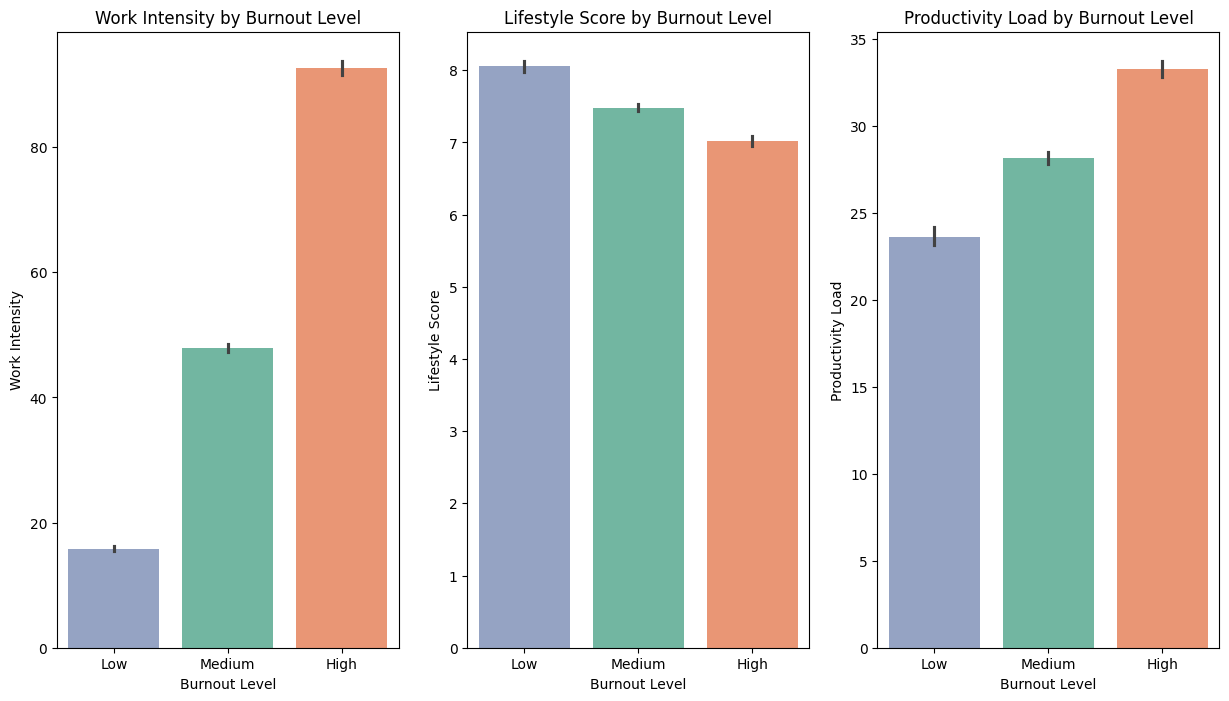

In [60]:
plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
sb.barplot(data=bu,x="Burnout Level",y="Work Intensity",palette="Set2",order=["Low","Medium","High"],hue="Burnout Level")
plt.title("Work Intensity by Burnout Level")
plt.subplot(1,3,2)
sb.barplot(data=bu,x="Burnout Level",y="Lifestyle Score",palette="Set2",order=["Low","Medium","High"],hue="Burnout Level")
plt.title("Lifestyle Score by Burnout Level")
plt.subplot(1,3,3)
sb.barplot(data=bu,x="Burnout Level",y="Productivity Load",palette="Set2",order=["Low","Medium","High"],hue="Burnout Level")
plt.title("Productivity Load by Burnout Level")
plt.show()

A subplot visualization was created using Matplotlib and Seaborn to compare multiple variables across different burnout levels. The figure contains three bar charts displayed side by side, each representing the average value of a different metric grouped by burnout level.

Work intensity increases significantly as burnout levels rise. Developers with high burnout exhibit substantially higher work intensity compared to those with low burnout, suggesting that increased workload is strongly associated with burnout.

Lifestyle score decreases as burnout levels increase. Developers with higher burnout tend to have poorer lifestyle habits, indicating a negative relationship between lifestyle quality and burnout.

Productivity load increases with burnout levels. Developers experiencing higher burnout are associated with higher productivity demands, including more tasks and workload pressure.

The small black lines on top of each bar represent confidence intervals (error bars), which indicate the variability of the data around the mean. In this case, the error bars are relatively small, suggesting that the average values are consistent within each burnout group.

Overall, the results suggest that higher burnout levels are associated with increased workload and reduced lifestyle quality. These findings indicate that both professional demands and personal habits play a significant role in developer burnout.

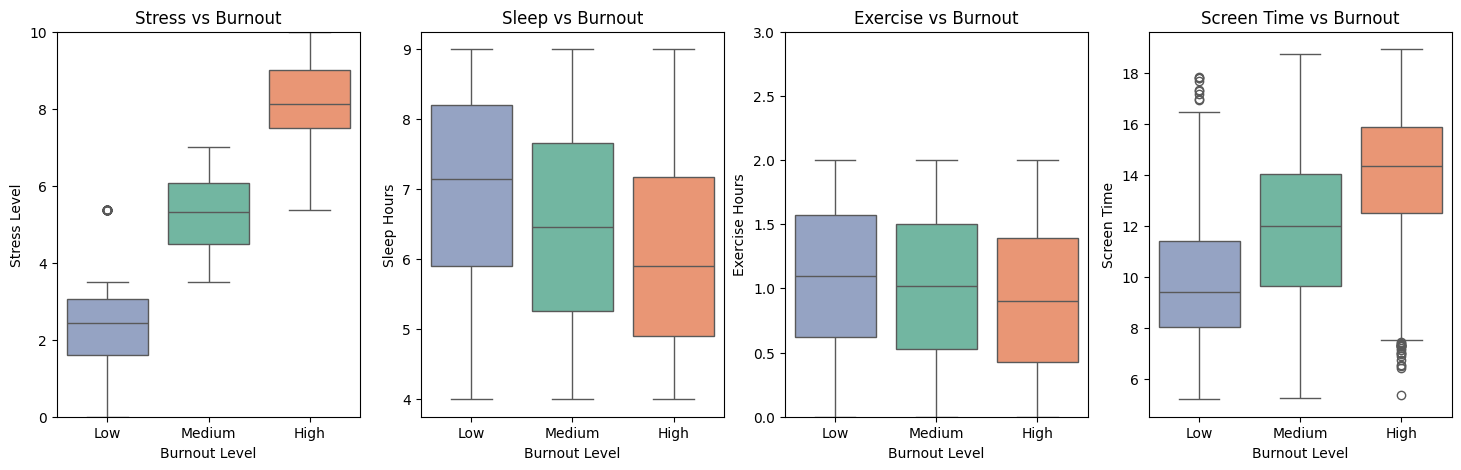

In [61]:
plt.figure(figsize=(18,5))
plt.subplot(1,4,1)
sb.boxplot(data=bu,x="Burnout Level",y="Stress Level",palette="Set2",hue="Burnout Level",order=["Low","Medium","High"])
plt.title("Stress vs Burnout")
plt.ylim(0,10) # to set the range for the y axis so it will start at 0 and end at 10
plt.subplot(1,4,2)
sb.boxplot(data=bu,x="Burnout Level",y="Sleep Hours",palette="Set2",hue="Burnout Level",order=["Low","Medium","High"])
plt.title("Sleep vs Burnout")
plt.subplot(1,4,3)
sb.boxplot(data=bu,x="Burnout Level",y="Exercise Hours",palette="Set2",hue="Burnout Level",order=["Low","Medium","High"])
plt.title("Exercise vs Burnout")
plt.ylim(0,3) # to set the range for the y axis so it will start at 0 and end at 10
plt.subplot(1,4,4)
sb.boxplot(data=bu,x="Burnout Level",y="Screen Time",palette="Set2",hue="Burnout Level",order=["Low","Medium","High"])
plt.title("Screen Time vs Burnout")
plt.show()

In this stage of the analysis, boxplot visualizations were created using Seaborn to examine the distribution of key lifestyle factors across different burnout levels. A subplot layout was used to display multiple variables side by side, allowing for easy comparison. Each boxplot represents the spread of the data, including the median, interquartile range, and outliers. This approach provides deeper insight beyond simple averages by highlighting variability and extreme values within each burnout group.

The results reveal clear and consistent patterns across all variables. Stress levels increase significantly as burnout levels rise, while sleep and exercise show a decreasing trend. In contrast, screen time increases with higher burnout levels. These findings indicate that higher burnout is associated with increased mental strain and less healthy lifestyle behaviors. Additionally, the presence of outliers and wider distributions in higher burnout groups suggests greater variability in behavior among highly burned-out individuals.

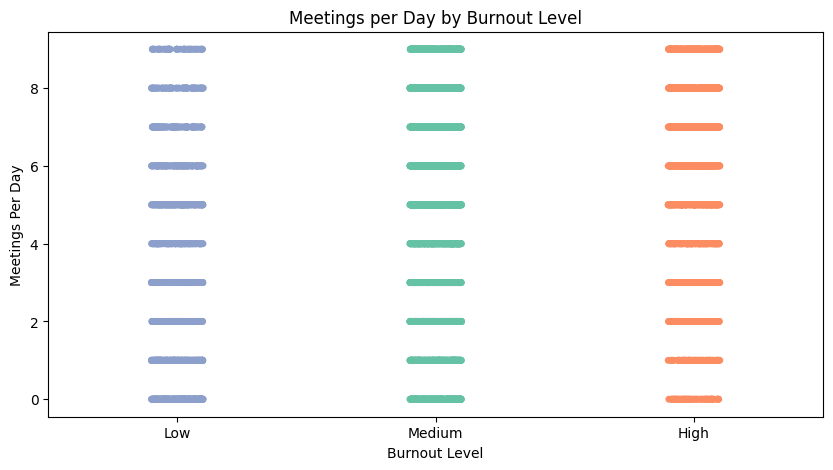

In [62]:
plt.figure(figsize=(10,5))
sb.stripplot(data=bu, x="Burnout Level",y="Meetings Per Day",hue="Burnout Level",order=["Low","Medium","High"],palette=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title("Meetings per Day by Burnout Level")
plt.show()

A stripplot was created using Seaborn to visualize the distribution of meetings per day across different burnout levels. Each point represents an individual observation, allowing for a detailed view of how meeting frequency varies within each group. The plot was customized with jitter and transparency to reduce overlap and improve readability.

The stripplot illustrates that meetings per day are similarly distributed across burnout groups, indicating no strong association between meeting frequency and burnout.

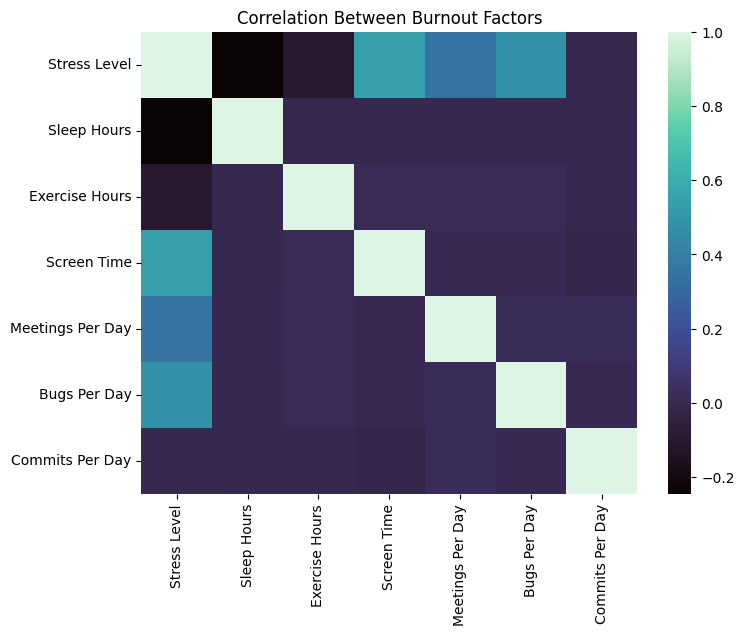

In [63]:
plt.figure(figsize=(8,6))
sb.heatmap(bu[["Stress Level","Sleep Hours","Exercise Hours",
    "Screen Time","Meetings Per Day","Bugs Per Day","Commits Per Day"]].corr(), cmap="mako")
plt.title("Correlation Between Burnout Factors")
plt.show()

The heatmap shows how the different variables are related to each other. Lighter colors mean a stronger positive relationship, darker colors mean a negative relationship, and neutral colors mean little to no connection.

we can see that stress level is related to several factors. It increases with screen time, bugs per day, and slightly with meetings per day, and it decreases with sleep hours, meaning people who sleep less tend to be more stressed, people with more screen time experience more stress, people with more bugs experience ore stress.

we can see in the heatmap that the main correlations with the most change (positive or negitive) is stress Level with other factors and as we have seen in previous vesualizations the more an employee is stressed the more burnedout he is

**Conclusions**

ממצאים עיקריים:
מהניתוח עולה כי רמת השחיקה של מפתחים קשורה בעיקר לגורמים של עומס עבודה ואורח חיים. נמצא כי ככל שרמת הלחץ עולה, כך גם רמת השחיקה עולה. בנוסף, נמצא כי שעות שינה ופעילות גופנית יורדות ככל שרמת השחיקה עולה, בעוד שזמן מסך עולה. מבחינת מדדי עבודה, נמצא כי עומס עבודה, מספר באגים ופרודוקטיביות קשורים זה לזה, אך מספר פגישות ביום אינו מציג קשר חזק עם רמת השחיקה.

מן הממצאים עולה כי גורמים כמגון לחץ עומס עבודה וזמן מסך מהווים משתנים מרכזיים הקשורים לרמת השחיקהת לעומתם משתנים כמו מספר הפגישות ביום אינם מציגים קשר מובהק לשחיקה ולכן נראה כי תרומתם להבר התופעה מוגבלתת בנוסף, נמצא כי יש קשר הפוך בין גורמי אורח חיים כמו שעות שינה ופעילות גופנית מציגים קשר הפוך לשחיקה מה שמדגיש את חשיבותם על מנת למזער את רמת השחיקה.

ניתן להסביר את הממצאים בכך שעומס עבודה גבוה ולחץ גורמים לעייפות מצטברת ולשחיקה. בנוסף, עלייה בזמן מסך עשויה להעיד על עבודה ממושכת או חוסר איזון בין עבודה למנוחה. ירידה בשעות שינה ובפעילות גופנית עשויה להיות תוצאה של עומס יתר, מה שמחמיר את תחושת השחיקה.

למחקר עתידי ניתן להעמיק בבחינת גורמים נוספים כגון סביבת העבודה, רמת התמיכה הארגונית והאיזון בין עבודה לחיים אישיים. בנוסף, ניתן לבחון את השפעת הגורמים השונים לאורך זמן כדי להבין כיצד הם משפיעים על התפתחות השחיקה. מבחינה מעשית, מומלץ לארגונים לצמצם עומסי עבודה מיותרים, לעודד איזון בין עבודה למנוחה, ולתמוך באימוץ הרגלים בריאים כגון שינה מספקת ופעילות גופנית, במטרה להפחית את רמת השחיקה בקרב עובדים.